# GWHD 2021: AP by Score Tertile

This notebook takes two inputs:

- a `score_results.json` file
- a YOLO weight file (`best.pt`)

It splits the image difficulty scores into 3 parts: low 30%, mid 30%, and top 30%. For each part, it evaluates the model on that subset and reports COCO AP and AP-by-size metrics.

The final table includes the tertile mean and std of the difficulty scores, plus the AP results for each part.

In [2]:
from pathlib import Path
import json
import math
import os
import shutil
import sys
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('/home/khanh/Projects/DifficultyAgri')
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from dagri.baseline import Baseline
from dagri.interfaces import BaselineConfig, DatasetProperties, EvaluationConfig, TrainingConfig

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

SCORE_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_3_Scoring_Dataset/score_results.json'
WEIGHT_PATH = BASE_DIR / '.cache_result/no_trad_aug/gwhd_2021/baseline/seed_123/best.pt'
TRAIN_CSV = BASE_DIR / 'datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv'
YOLO_ROOT = BASE_DIR / 'datasets/global_wheat_head/yolo_format_v2'
SOURCE_IMAGE_DIR = YOLO_ROOT / 'train/images'
SOURCE_LABEL_DIR = YOLO_ROOT / 'train/labels'
N_PARTS = 3
PART_LABELS = ['low_30', 'mid_30', 'top_30']

print('Score path exists:', SCORE_PATH.exists())
print('Weight path exists:', WEIGHT_PATH.exists())
print('Training CSV exists:', TRAIN_CSV.exists())
print('YOLO image dir exists:', SOURCE_IMAGE_DIR.exists())
print('YOLO label dir exists:', SOURCE_LABEL_DIR.exists())

if not SCORE_PATH.exists():
    raise FileNotFoundError(f'Missing score file: {SCORE_PATH}')
if not WEIGHT_PATH.exists():
    raise FileNotFoundError(f'Missing weight file: {WEIGHT_PATH}')
if not TRAIN_CSV.exists():
    raise FileNotFoundError(f'Missing training CSV: {TRAIN_CSV}')
if not SOURCE_IMAGE_DIR.exists() or not SOURCE_LABEL_DIR.exists():
    raise FileNotFoundError('Missing YOLO train images/labels directories')

with open(SCORE_PATH, 'r', encoding='utf-8') as f:
    score_data = json.load(f)

train_df = pd.read_csv(TRAIN_CSV)

score_rows = []
for item in score_data.get('image_difficulties', []):
    image_path = item.get('image_path', '')
    if not image_path:
        continue
    score_rows.append({
        'image_name': Path(image_path).name,
        'image_path': image_path,
        'difficulty_score': float(item.get('difficulty_score', np.nan)),
        'num_objects': float(item.get('num_objects', np.nan)),
        'false_positive_rate': float(item.get('false_positive_rate', np.nan)),
        'missed_detections_rate': float(item.get('missed_detections_rate', np.nan)),
    })

score_df = pd.DataFrame(score_rows).dropna(subset=['image_name', 'difficulty_score']).copy()
filename_to_domain = dict(zip(train_df['image_name'], train_df['domain']))
score_df['domain'] = score_df['image_name'].map(filename_to_domain)
score_df = score_df.dropna(subset=['domain']).copy()

q30 = score_df['difficulty_score'].quantile(0.30)
q70 = score_df['difficulty_score'].quantile(0.70)

def tertile_label(score: float) -> str:
    if score <= q30:
        return 'low_30'
    if score >= q70:
        return 'top_30'
    return 'mid_30'

score_df['score_tertile'] = score_df['difficulty_score'].apply(tertile_label)
score_df['score_tertile'] = pd.Categorical(score_df['score_tertile'], categories=PART_LABELS, ordered=True)

print(f'Loaded score rows: {len(score_df)}')
print(f'Low/mid threshold: {q30:.4f}')
print(f'Mid/top threshold: {q70:.4f}')
print(score_df.groupby('score_tertile').size().reindex(PART_LABELS).to_string())

Score path exists: True
Weight path exists: True
Training CSV exists: True
YOLO image dir exists: True
YOLO label dir exists: True
Loaded score rows: 3655
Low/mid threshold: 0.2681
Mid/top threshold: 0.3662
score_tertile
low_30    1097
mid_30    1461
top_30    1097


Domain share inside each tertile:
domain         Arvalis_1  Arvalis_10  Arvalis_11  Arvalis_12  Arvalis_2  Arvalis_3  Arvalis_4  Arvalis_5  Arvalis_6  Arvalis_7  Arvalis_8  Arvalis_9  ETHZ_1  Inrae_1  NMBU_1  NMBU_2  Rres_1  ULiège-GxABT_1
score_tertile                                                                                                                                                                                                
low_30             0.002       0.047       0.005       0.000      0.002      0.015      0.000      0.100      0.047      0.000      0.002      0.000   0.344    0.087   0.002   0.026   0.321           0.000
mid_30             0.015       0.003       0.021       0.005      0.098      0.235      0.006      0.107      0.068      0.005      0.008      0.010   0.245    0.041   0.041   0.034   0.052           0.005
top_30             0.038       0.001       0.023       0.020      0.233      0.207      0.178      0.165      0.008      0.015      0.005     

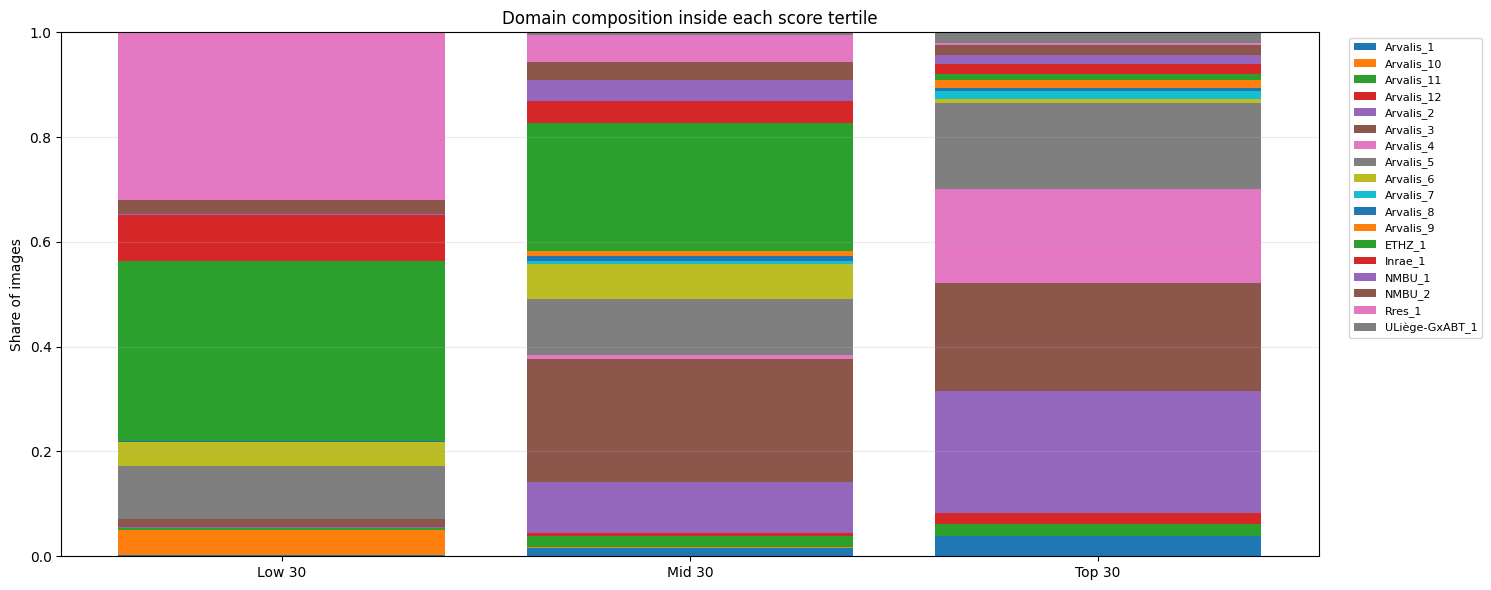

In [3]:
# Tertile composition by domain.
domain_counts_by_part = (
    score_df.groupby(['score_tertile', 'domain'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=PART_LABELS, fill_value=0)
)
domain_share_by_part = domain_counts_by_part.div(domain_counts_by_part.sum(axis=1), axis=0).fillna(0)

majority_rows = []
for part in PART_LABELS:
    counts = domain_counts_by_part.loc[part].sort_values(ascending=False)
    top_domain = counts.index[0]
    top_share = float(counts.iloc[0] / counts.sum()) if counts.sum() else np.nan
    majority_rows.append({
        'part': part,
        'majority_domain': top_domain,
        'majority_domain_share': top_share,
        'part_size': int(counts.sum()),
    })

majority_df = pd.DataFrame(majority_rows)
print('Domain share inside each tertile:')
print(domain_share_by_part.round(3).to_string())
print()
print('Majority domain inside each tertile:')
print(majority_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(PART_LABELS))
x = np.arange(len(PART_LABELS))
for domain in domain_share_by_part.columns:
    vals = domain_share_by_part[domain].values
    ax.bar(x, vals, bottom=bottom, label=domain)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(['Low 30', 'Mid 30', 'Top 30'])
ax.set_ylabel('Share of images')
ax.set_title('Domain composition inside each score tertile')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [4]:
# Parse the GWHD BoxesString column to describe the object profile of each tertile.
def parse_boxes_string(boxes_string: str):
    if not isinstance(boxes_string, str) or not boxes_string.strip():
        return []
    boxes = []
    for raw_box in boxes_string.split(';'):
        raw_box = raw_box.strip()
        if not raw_box:
            continue
        parts = raw_box.split()
        if len(parts) < 4:
            continue
        x1, y1, x2, y2 = map(float, parts[:4])
        width = max(0.0, x2 - x1)
        height = max(0.0, y2 - y1)
        area_px = width * height
        equiv_side = math.sqrt(area_px) if area_px > 0 else 0.0
        boxes.append({
            'area_px': area_px,
            'equiv_side': equiv_side,
        })
    return boxes

def size_bucket_from_side(side_px: float) -> str:
    if side_px < 20:
        return 'very_small'
    if side_px < 32:
        return 'small'
    if side_px < 96:
        return 'medium'
    return 'large'

object_rows = []
for row in train_df.itertuples(index=False):
    boxes = parse_boxes_string(getattr(row, 'BoxesString'))
    for box in boxes:
        object_rows.append({
            'image_name': getattr(row, 'image_name'),
            'domain': getattr(row, 'domain'),
            'area_px': box['area_px'],
            'equiv_side': box['equiv_side'],
            'size_bucket': size_bucket_from_side(box['equiv_side']),
        })

object_df = pd.DataFrame(object_rows)
object_df['size_bucket'] = pd.Categorical(object_df['size_bucket'], categories=['very_small', 'small', 'medium', 'large'], ordered=True)

image_object_stats = (
    object_df.groupby(['image_name', 'domain'])
    .agg(
        n_objects=('area_px', 'size'),
        mean_object_area=('area_px', 'mean'),
        mean_equiv_side=('equiv_side', 'mean'),
        pct_very_small=('size_bucket', lambda s: 100 * (s == 'very_small').mean()),
        pct_small=('size_bucket', lambda s: 100 * (s == 'small').mean()),
        pct_medium=('size_bucket', lambda s: 100 * (s == 'medium').mean()),
        pct_large=('size_bucket', lambda s: 100 * (s == 'large').mean()),
    )
    .reset_index()
)

image_tertile_df = score_df.merge(image_object_stats, on=['image_name', 'domain'], how='inner')

tertile_object_summary = image_tertile_df.groupby('score_tertile').agg(
    n_images=('image_name', 'count'),
    score_mean=('difficulty_score', 'mean'),
    score_std=('difficulty_score', 'std'),
    mean_objects=('n_objects', 'mean'),
    std_objects=('n_objects', 'std'),
    mean_object_area=('mean_object_area', 'mean'),
    std_object_area=('mean_object_area', 'std'),
    pct_very_small=('pct_very_small', 'mean'),
    pct_small=('pct_small', 'mean'),
    pct_medium=('pct_medium', 'mean'),
    pct_large=('pct_large', 'mean'),
).reindex(PART_LABELS)

print('Object profile by tertile:')
print(tertile_object_summary.round(4).to_string())

part_domain_detail = (
    image_tertile_df.groupby(['score_tertile', 'domain'])
    .agg(
        n_images=('image_name', 'count'),
        mean_score=('difficulty_score', 'mean'),
        mean_objects=('n_objects', 'mean'),
        mean_object_area=('mean_object_area', 'mean'),
        pct_very_small=('pct_very_small', 'mean'),
        pct_small=('pct_small', 'mean'),
        pct_medium=('pct_medium', 'mean'),
        pct_large=('pct_large', 'mean'),
    )
    .reset_index()
    .sort_values(['score_tertile', 'n_images'], ascending=[True, False])
)

for part in PART_LABELS:
    block = part_domain_detail[part_domain_detail['score_tertile'] == part].copy()
    block['share_in_part'] = block['n_images'] / block['n_images'].sum()
    print(f'\nTop domains in {part}:')
    print(block[['domain', 'n_images', 'share_in_part', 'mean_score', 'mean_objects', 'mean_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large']].head(5).round(4).to_string(index=False))

Object profile by tertile:
               n_images  score_mean  score_std  mean_objects  std_objects  mean_object_area  std_object_area  pct_very_small  pct_small  pct_medium  pct_large
score_tertile                                                                                                                                                 
low_30             1064      0.2272     0.0285       48.0940      19.6159         6991.6240        3515.1837          0.0160     0.3590     79.5847    20.0403
mid_30             1461      0.3143     0.0276       48.9103      20.2371         7224.6250        4211.2508          0.0979     0.9819     77.3803    21.5399
top_30             1080      0.4515     0.1053       37.9824      19.8479         6789.8294        3939.8618          0.0957     1.2389     79.4649    19.2006

Top domains in low_30:
   domain  n_images  share_in_part  mean_score  mean_objects  mean_object_area  pct_very_small  pct_small  pct_medium  pct_large
   ETHZ_1       377      

In [5]:
# Evaluate the baseline weight on each tertile subset using the repo's COCO evaluation path.
baseline_config = BaselineConfig(
    name='yolov8s',
    model_type='yolo',
    pretrained_weights_path=str(WEIGHT_PATH),
    training_config=TrainingConfig(
        epochs=1,
        batch_size=1,
        input_size=1024,
        learning_rate=0.01,
        seed=123,
        early_stopping_patience=1,
        traditional_augmentation_config={},
    ),
    evaluation_config=EvaluationConfig(
        image_size=1024,
        confidence_threshold=0.001,
        iou_threshold=0.5,
        max_detections=10000,
    ),
)

baseline_model = Baseline(baseline_config)

def link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return
    try:
        dst.symlink_to(src)
    except OSError:
        shutil.copy2(src, dst)

def evaluate_part(part_name: str, part_df: pd.DataFrame) -> dict:
    image_names = part_df['image_name'].tolist()
    with tempfile.TemporaryDirectory(prefix=f'gwhd_{part_name}_') as tmp_dir:
        tmp_root = Path(tmp_dir)
        test_images_dir = tmp_root / 'test' / 'images'
        test_labels_dir = tmp_root / 'test' / 'labels'
        test_images_dir.mkdir(parents=True, exist_ok=True)
        test_labels_dir.mkdir(parents=True, exist_ok=True)

        for image_name in image_names:
            src_img = Path(score_df.loc[score_df['image_name'] == image_name, 'image_path'].iloc[0])
            src_lbl = SOURCE_LABEL_DIR / f'{Path(image_name).stem}.txt'
            dst_img = test_images_dir / image_name
            dst_lbl = test_labels_dir / src_lbl.name
            link_or_copy(src_img, dst_img)
            link_or_copy(src_lbl, dst_lbl)

        dataset_props = DatasetProperties(
            root_dir=str(tmp_root),
            num_classes=1,
            class_names=['wheat_head'],
            test_images_dir=str(test_images_dir),
            test_labels_dir=str(test_labels_dir),
        )

        eval_results = baseline_model.custom_evaluate_on_test_set(str(WEIGHT_PATH), dataset_props)

        return {
            'part': part_name,
            'n_images': len(image_names),
            'COCO_AP': float(eval_results.COCO_AP),
            'COCO_AP50': float(eval_results.COCO_AP50),
            'COCO_AP75': float(eval_results.COCO_AP75),
            'AP_small': float(eval_results.AP_small),
            'AP_medium': float(eval_results.AP_medium),
            'AP_large': float(eval_results.AP_large),
            'AP_very_small': float(eval_results.AP_very_small),
            'AP_small_20_32': float(eval_results.AP_small_20_32),
            'AP_medium_gt_32': float(eval_results.AP_medium_gt_32),
        }

eval_rows = []
for part in PART_LABELS:
    part_df = score_df[score_df['score_tertile'] == part].copy()
    print(f'Evaluating {part} with {len(part_df)} images...')
    eval_rows.append(evaluate_part(part, part_df))

eval_df = pd.DataFrame(eval_rows).set_index('part').reindex(PART_LABELS)
print('\nAP results by tertile:')
print(eval_df.round(4).to_string())

Evaluating low_30 with 1097 images...
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11297.3±574.7 MB/s, size: 1546.0 KB)


/home/khanh/Projects/DifficultyAgri/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


val: Scanning /tmp/gwhd_low_30_rh9dqeuq/test/labels... 1097 images, 33 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1097/1097 519.7it/s 2.1s0.1s
val: /tmp/gwhd_low_30_rh9dqeuq/test/images/502d5e4a8b89aeffaa6adf13e1215d27c2951230ab06a4fcb93732117196f124.png: 1 duplicate labels removed
val: New cache created: /tmp/gwhd_low_30_rh9dqeuq/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 15.1it/s 4.6s0.1s
                   all       1097      51171      0.961      0.961      0.986      0.667
Speed: 0.6ms preprocess, 2.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Saving /tmp/eval_test_f4cdnkyt/evaluation/predictions.json...
Results saved to /tmp/eval_test_f4cdnkyt/evaluation
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.16s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE 

Final summary table:
  part  part_size majority_domain  majority_domain_share  score_mean  score_std  mean_objects  std_objects  mean_object_area  std_object_area  pct_very_small  pct_small  pct_medium  pct_large  COCO_AP  COCO_AP50  COCO_AP75  AP_very_small  AP_small  AP_small_20_32  AP_medium  AP_medium_gt_32  AP_large
low_30       1097          ETHZ_1                 0.3437      0.2272     0.0285       48.0940      19.6159         6991.6240        3515.1837          0.0160     0.3590     79.5847    20.0403   0.6713     0.9819     0.8015         0.1428    0.2801          0.2901     0.6629           0.6719    0.7276
mid_30       1461          ETHZ_1                 0.2450      0.3143     0.0276       48.9103      20.2371         7224.6250        4211.2508          0.0979     0.9819     77.3803    21.5399   0.5678     0.9511     0.6050         0.0874    0.3062          0.3299     0.5599           0.5717    0.6256
top_30       1097       Arvalis_2                 0.2334      0.4515     

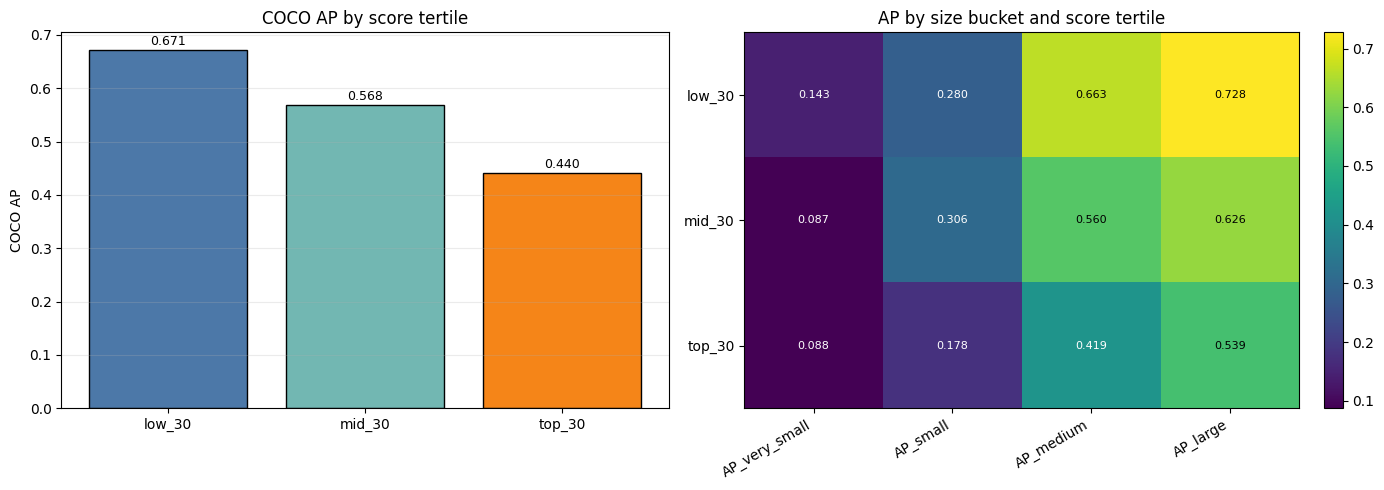


Interpretation:
- The majority domain tells you which domain dominates each tertile.
- The object-profile columns show whether the top tertile is driven by many small objects, dense scenes, or both.
- The AP columns show the model quality on each tertile-specific subset.
- The heatmap makes it easy to compare whether top-score images are also the ones with weak AP on tiny objects.


In [6]:
# Final summary table: tertile mean/std plus AP results.
summary_df = majority_df.merge(tertile_object_summary.reset_index().rename(columns={'score_tertile': 'part'}), on='part', how='left')
summary_df = summary_df.merge(eval_df.reset_index().rename(columns={'part': 'part'}), on='part', how='left')
summary_df = summary_df[['part', 'part_size', 'majority_domain', 'majority_domain_share', 'score_mean', 'score_std', 'mean_objects', 'std_objects', 'mean_object_area', 'std_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large', 'COCO_AP', 'COCO_AP50', 'COCO_AP75', 'AP_very_small', 'AP_small', 'AP_small_20_32', 'AP_medium', 'AP_medium_gt_32', 'AP_large']]

print('Final summary table:')
print(summary_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(summary_df['part'], summary_df['COCO_AP'], color=['#4c78a8', '#72b7b2', '#f58518'], edgecolor='black')
axes[0].set_ylabel('COCO AP')
axes[0].set_title('COCO AP by score tertile')
axes[0].grid(axis='y', alpha=0.25)
for idx, val in enumerate(summary_df['COCO_AP']):
    axes[0].text(idx, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

metrics_to_plot = ['AP_very_small', 'AP_small', 'AP_medium', 'AP_large']
metric_table = summary_df.set_index('part')[metrics_to_plot]
im = axes[1].imshow(metric_table.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(metrics_to_plot)))
axes[1].set_xticklabels(metrics_to_plot, rotation=30, ha='right')
axes[1].set_yticks(range(len(summary_df)))
axes[1].set_yticklabels(summary_df['part'])
axes[1].set_title('AP by size bucket and score tertile')
for i in range(metric_table.shape[0]):
    for j in range(metric_table.shape[1]):
        axes[1].text(j, i, f'{metric_table.values[i, j]:.3f}', ha='center', va='center', color='white' if metric_table.values[i, j] < metric_table.values.max() * 0.6 else 'black', fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- The majority domain tells you which domain dominates each tertile.')
print('- The object-profile columns show whether the top tertile is driven by many small objects, dense scenes, or both.')
print('- The AP columns show the model quality on each tertile-specific subset.')
print('- The heatmap makes it easy to compare whether top-score images are also the ones with weak AP on tiny objects.')

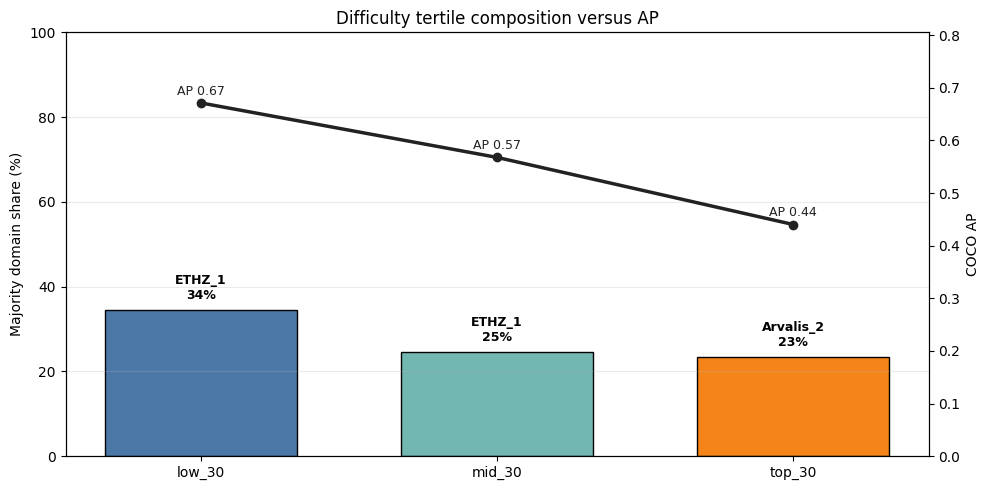

How to read this chart:
- The bar height shows how concentrated each tertile is in one dominant domain.
- The line shows AP for the same tertile.
- If the low-difficulty bar is dominated by ETHZ_1/Rres_1 and sits higher on AP, while the high-difficulty bar is dominated by Arvalis variants and sits lower, the chart directly shows that tradeoff.


In [7]:
# Spotlight chart: dominant-domain share versus AP for each difficulty tertile.
# This is the most direct way to show the pattern described as
# "low difficulty -> mostly ETHZ_1/Rres_1 with higher AP" and
# "high difficulty -> mostly Arvalis variants with lower AP".
spotlight_df = summary_df[['part', 'majority_domain', 'majority_domain_share', 'COCO_AP']].copy()
spotlight_df['majority_domain_share_pct'] = 100 * spotlight_df['majority_domain_share']
spotlight_df['COCO_AP'] = spotlight_df['COCO_AP'].astype(float)

fig, ax1 = plt.subplots(figsize=(10, 5))
bar_colors = ['#4c78a8', '#72b7b2', '#f58518']
ax1.bar(
    spotlight_df['part'],
    spotlight_df['majority_domain_share_pct'],
    color=bar_colors,
    edgecolor='black',
    width=0.65,
)
ax1.set_ylabel('Majority domain share (%)')
ax1.set_ylim(0, 100)
ax1.set_title('Difficulty tertile composition versus AP')
ax1.grid(axis='y', alpha=0.25)

for idx, row in enumerate(spotlight_df.itertuples(index=False)):
    ax1.text(
        idx,
        row.majority_domain_share_pct + 2,
        f'{row.majority_domain}\n{row.majority_domain_share_pct:.0f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
    )

ax2 = ax1.twinx()
ax2.plot(
    spotlight_df['part'],
    spotlight_df['COCO_AP'],
    color='#222222',
    marker='o',
    linewidth=2.5,
)
ax2.set_ylabel('COCO AP')
ax2.set_ylim(0, max(0.1, float(spotlight_df['COCO_AP'].max()) * 1.2))

for idx, row in enumerate(spotlight_df.itertuples(index=False)):
    ax2.text(
        idx,
        row.COCO_AP + 0.01,
        f'AP {row.COCO_AP:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#222222',
    )

plt.tight_layout()
plt.show()

print('How to read this chart:')
print('- The bar height shows how concentrated each tertile is in one dominant domain.')
print('- The line shows AP for the same tertile.')
print('- If the low-difficulty bar is dominated by ETHZ_1/Rres_1 and sits higher on AP, while the high-difficulty bar is dominated by Arvalis variants and sits lower, the chart directly shows that tradeoff.')